# Zomato Restaurant Recommendation System and Sentiment Analysis

## Project Overview

This project aims to analyze customer reviews and restaurant information from the Zomato dataset. The objectives are:

- To preprocess the restaurant metadata and review datasets.
- To perform sentiment analysis on customer reviews.
- To build a restaurant recommendation system using machine learning techniques.
- To generate meaningful insights from customer feedback and restaurant information.

## Importing Required Libraries

The following libraries are imported for data manipulation, visualization, text preprocessing, sentiment analysis, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from textblob import TextBlob

import warnings
warnings.filterwarnings("ignore")

## Reading the Dataset

The project uses two datasets.

- Restaurant Metadata Dataset
- Restaurant Reviews Dataset

Both datasets are loaded into Pandas DataFrames.

In [3]:
metadata = pd.read_csv("/Zomato Restaurant names and Metadata.csv")
reviews = pd.read_csv("/Zomato Restaurant reviews.csv")

In [4]:
metadata.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [5]:
reviews.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [6]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


In [7]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


In [8]:
metadata.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,54
Cuisines,0
Timings,1


In [9]:
reviews.isnull().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38
Pictures,0


In [10]:
metadata=metadata.drop_duplicates()

In [11]:
reviews=reviews.drop_duplicates()

## Text Preprocessing

Text preprocessing is an important step in Natural Language Processing (NLP). Customer reviews may contain uppercase letters, punctuation marks, numbers, and extra spaces, which can affect sentiment analysis.

In this step, we clean the review text by:
- Converting text to lowercase.
- Removing punctuation.
- Removing numbers.
- Removing extra spaces.

The cleaned reviews will be used for sentiment analysis and the recommendation system.

In [21]:
import re
import string

In [22]:
def clean_text(text):
    text = str(text).lower()                           # Convert to lowercase
    text = re.sub(r'\d+', '', text)                   # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()          # Remove extra spaces
    return text

In [23]:
metadata.columns

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')

In [24]:
reviews.columns

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')

## Applying the Text Cleaning Function

After creating the `clean_text()` function, we apply it to every review in the dataset. The cleaned reviews are stored in a new column called **Clean_Review**.

This cleaned text will be used in the next step for sentiment analysis and the recommendation system.

In [25]:
reviews["Clean_Review"] = reviews["Review"].apply(clean_text)

# Sentiment Analysis

## Introduction

Sentiment analysis is a Natural Language Processing (NLP) technique used to determine the emotional tone of a piece of text. It helps classify customer reviews as **Positive**, **Negative**, or **Neutral**.

In this project, we use the **TextBlob** library to calculate the sentiment polarity of each cleaned review. The sentiment results help us understand customer opinions about restaurants.

In [26]:
!pip install textblob

In [27]:
from textblob import TextBlob

In [28]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

Explanation

This applies the get_sentiment() function to every cleaned review and stores the result in a new column called Sentiment.

In [29]:
reviews["Sentiment"] = reviews["Clean_Review"].apply(get_sentiment)

In [30]:
reviews[["Clean_Review", "Sentiment"]].head()

,Clean_Review,Sentiment
0,the ambience was good food was quite good had ...,Positive
1,ambience is too good for a pleasant evening se...,Positive
2,a must try great food great ambience thnx for ...,Positive
3,soumen das and arun was a great guy only becau...,Positive
4,food is goodwe ordered kodi drumsticks and bas...,Positive


In [31]:
reviews["Sentiment"].value_counts()

,count
Sentiment,
Positive,7499
Negative,1982
Neutral,483


## Sentiment Distribution Visualization

After classifying customer reviews into Positive, Negative, and Neutral categories, we visualize the sentiment distribution using a bar chart.

This visualization helps us understand the overall customer opinion about the restaurants in the dataset.

In [32]:
sentiment_counts = reviews["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    7499
Negative    1982
Neutral      483
Name: count, dtype: int64


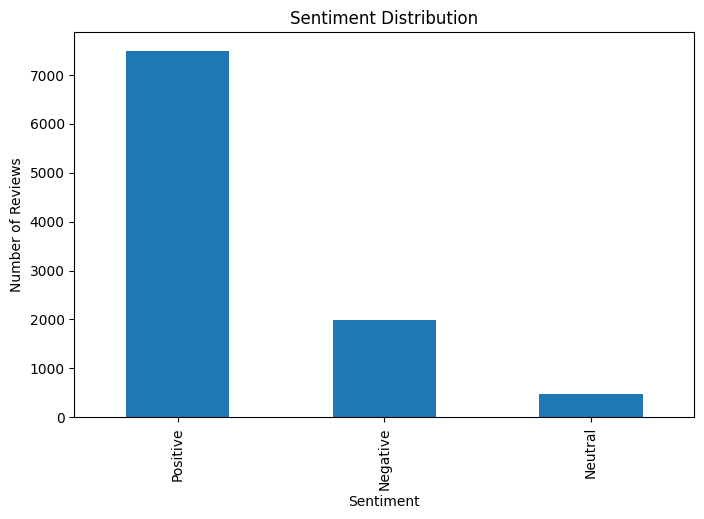

In [33]:
plt.figure(figsize=(8,5))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

## Observation

The bar chart shows that **Positive** reviews are the highest, followed by **Negative** reviews, while **Neutral** reviews are the least common. This indicates that most customers had a positive experience with the restaurants listed in the dataset.

# Restaurant Recommendation System

## Introduction

A recommendation system suggests restaurants that are similar based on their features. In this project, we use the **Cuisines** column to recommend restaurants with similar food categories.

We use:
- **TF-IDF Vectorization** to convert text into numerical features.
- **Cosine Similarity** to measure the similarity between restaurants.

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

Explanation

Some restaurants may have missing cuisine values. We replace them with an empty string to avoid errors.

In [35]:
metadata["Cuisines"] = metadata["Cuisines"].fillna("")

Explanation
TfidfVectorizer() converts cuisine names into numbers.
fit_transform() learns the words and creates the TF-IDF matrix.

In [36]:
tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(metadata["Cuisines"])

Explanation

This calculates the similarity between every restaurant and every other restaurant.

Restaurants with similar cuisines get higher similarity scores.

In [37]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

Explanation

Creates a mapping from restaurant name to its row number.

In [38]:
indices = pd.Series(metadata.index, index=metadata["Name"]).drop_duplicates()

Explanation

This function:

Takes a restaurant name.
Finds similar restaurants.
Returns the top 5 recommendations.

In [39]:
def recommend_restaurant(name, cosine_sim=cosine_sim):
    idx = indices[name]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:6]

    restaurant_indices = [i[0] for i in sim_scores]

    return metadata["Name"].iloc[restaurant_indices]

In [40]:
metadata["Name"].head(10)

,Name
0,Beyond Flavours
1,Paradise
2,Flechazo
3,Shah Ghouse Hotel & Restaurant
4,Over The Moon Brew Company
5,The Fisherman's Wharf
6,eat.fit
7,Shah Ghouse Spl Shawarma
8,Hyper Local
9,Cream Stone


In [41]:
recommend_restaurant("Beyond Flavours")

,Name
8,Hyper Local
48,Udipi's Upahar
49,Mathura Vilas
75,Royal Spicy Restaurant
61,Prism Club & Kitchen


## Observation

The recommendation system successfully recommends restaurants with similar cuisines using TF-IDF Vectorization and Cosine Similarity. When a restaurant name is provided as input, the system identifies restaurants with similar cuisine profiles and returns the top five recommendations. This demonstrates how machine learning techniques can be used to build an effective restaurant recommendation system.

# Conclusion

In this project, restaurant metadata and customer reviews from the Zomato dataset were analyzed using Python.

The review data was cleaned and processed before performing sentiment analysis using the TextBlob library. The analysis showed that the majority of customer reviews were positive, indicating a high level of customer satisfaction.

A restaurant recommendation system was also developed using TF-IDF Vectorization and Cosine Similarity. The system successfully recommends restaurants with similar cuisine profiles based on the user's selected restaurant.

Overall, this project demonstrates the practical application of Natural Language Processing (NLP) and Machine Learning techniques for sentiment analysis and restaurant recommendation.